In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

In [2]:
file_names = ['1d_aug_cc_energy.txt','1d_plus_d_energy.txt', '1d_f12_energy.txt']
energy_names = ['aug_cc', 'plus_d', 'f12']
hartree_to_cm = 219474.6313705

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])


0.0
0.0
0.0


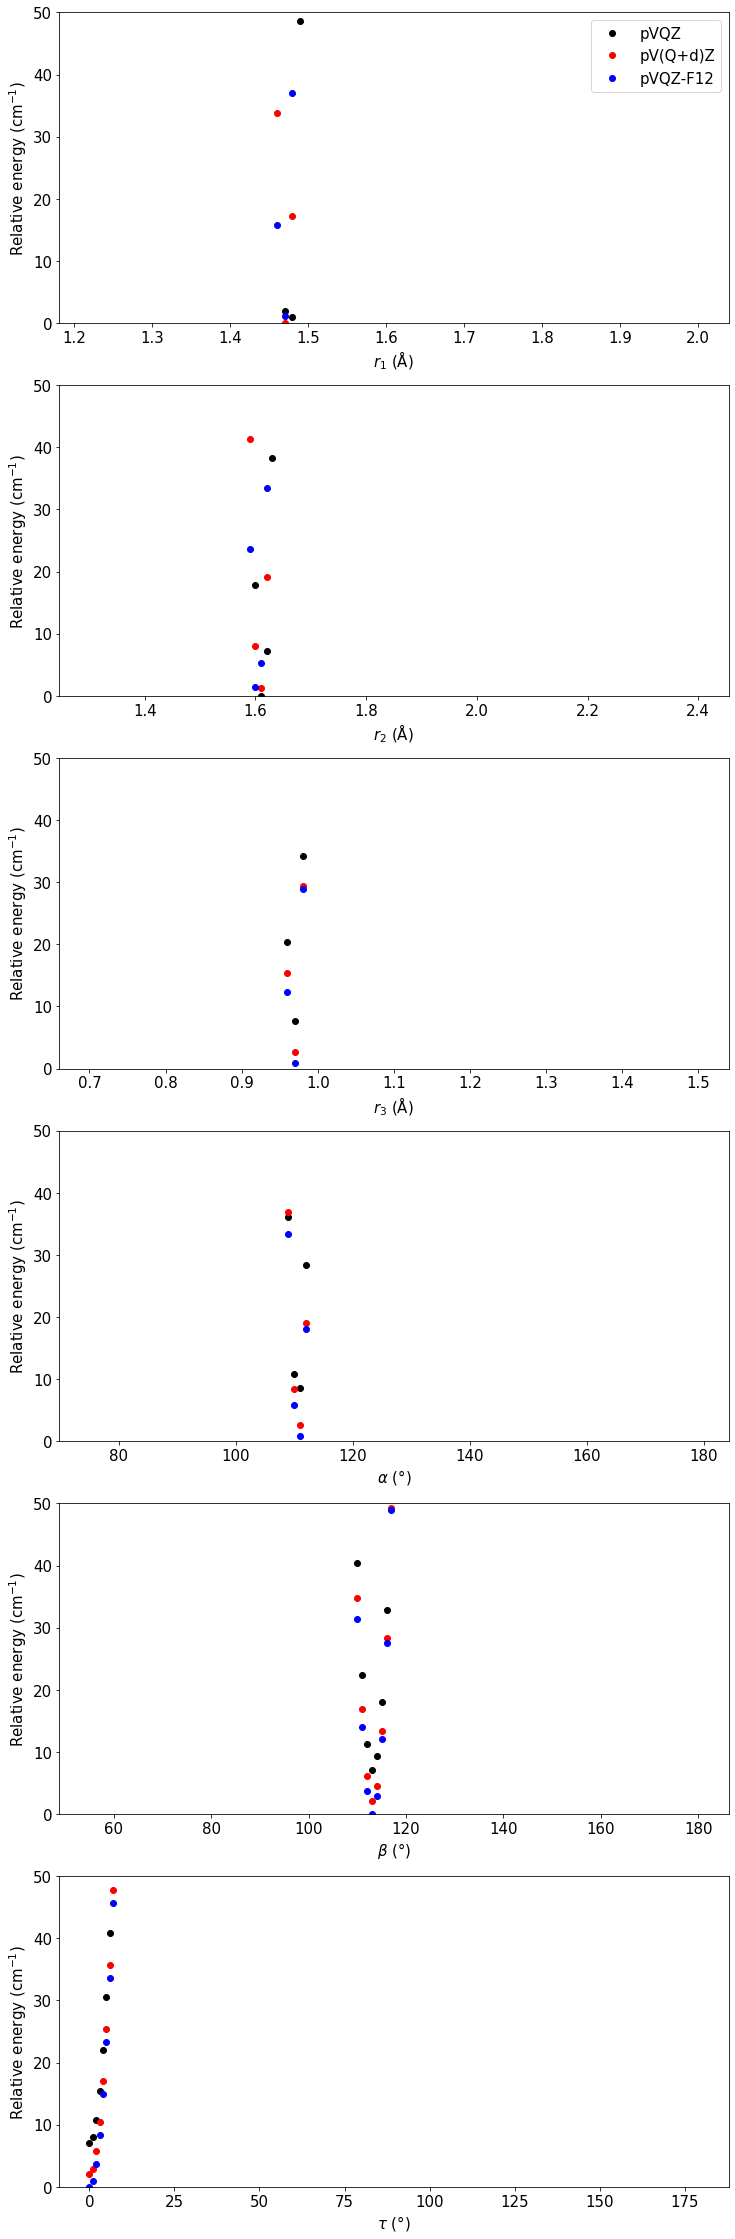

In [7]:
#initialize plot, different plot features
fig, ax = plt.subplots(6,1, figsize=(12,40))
idx = np.array([0,79,190,271,376,502,682])
energy_labels = ['pVQZ','pV(Q+d)Z','pVQZ-F12']
color = ['black', 'red', 'blue']
xlabels = [r'$r_{1}$ (Å)',r'$r_{2}$ (Å)',r'$r_{3}$ (Å)', r'$\alpha$ (°)', r'$\beta$ (°)', r'$\tau$ (°)']
ylabel = r'Relative energy (cm$^{-1}$)'

#load and plot energies for each coordinate
for i in range(3):
    coords, energy = load_coords_energy(file_names[i])
    print(min(energy))
    for j in range(6):
        ax[j].plot(coords[idx[j]:idx[j+1],j], energy[idx[j]:idx[j+1]],
                   'o',
                   color = f'{color[i]}',
                   label = f'{energy_labels[i]}')
        ax[j].set_xlabel(xlabels[j], size=15)
        ax[j].set_ylabel(ylabel, size=15)
        ax[j].tick_params(labelsize=15)
        ax[j].set_ylim(0,50)

ax[0].legend(fontsize=15);

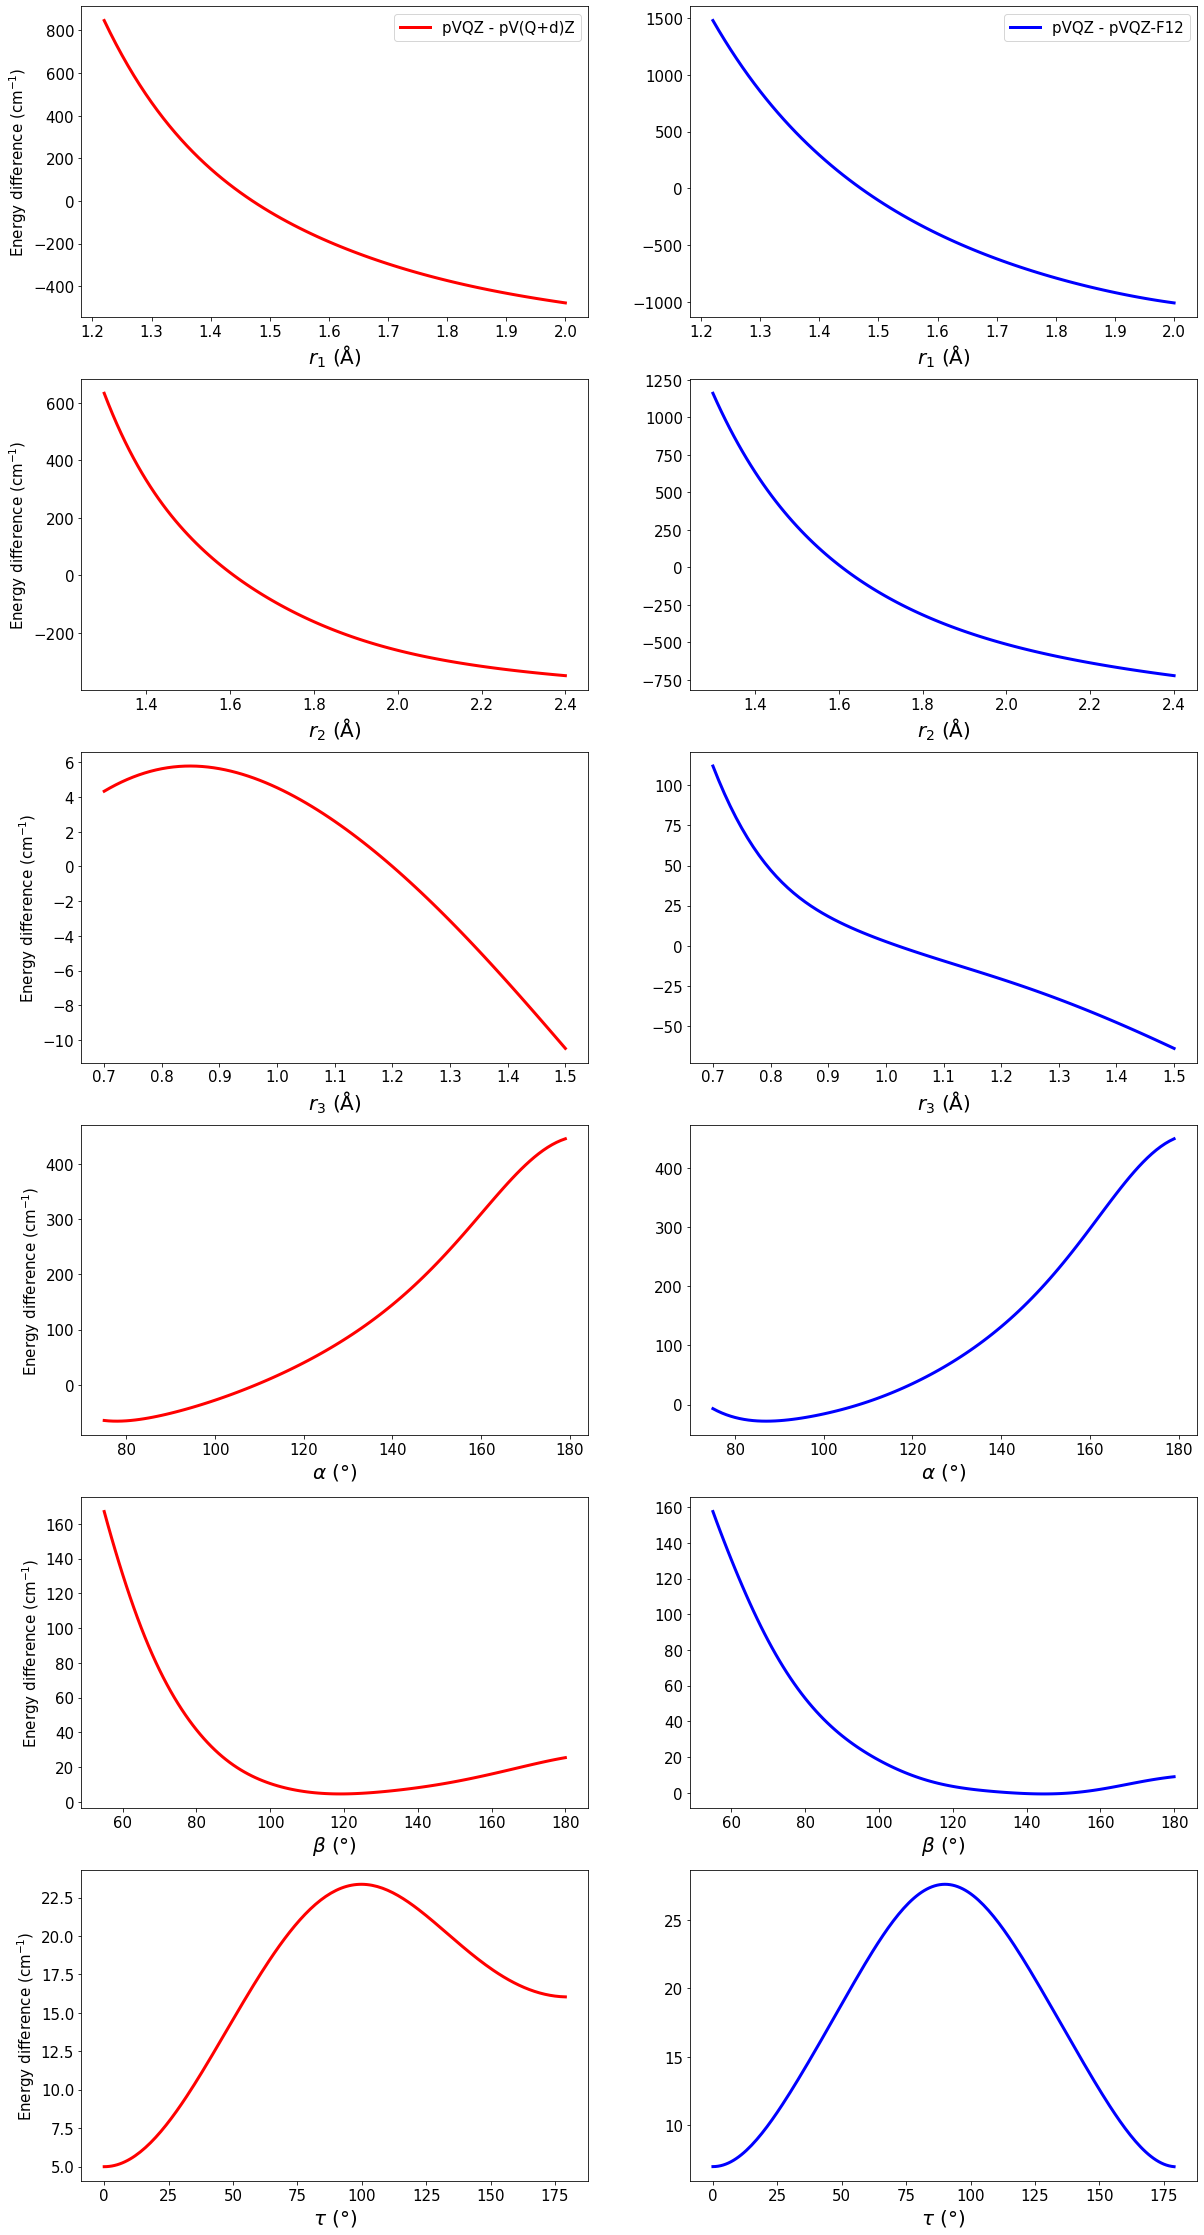

In [5]:
#initialize plot, different plot features
diff_labels = ['pVQZ - pV(Q+d)Z', 'pVQZ - pVQZ-F12']
fig, ax = plt.subplots(6,2, figsize=(20,40))
ylabel = r'Energy difference (cm$^{-1}$)'

#plot difference between aug pVQZ compared to aug pv(Q+d)z and pVQZ-F12b
for i in range(1,3):
    coords, energy = load_coords_energy(file_names[i])
    aug_cc = load_coords_energy(file_names[0])[1]
    energy_diff = aug_cc - energy 
    
    for j in range(6):
        ax[j,i-1].plot(coords[idx[j]:idx[j+1],j], energy_diff[idx[j]:idx[j+1]],
                   color = f'{color[i]}',
                   lw = 3,
                   label = f'{diff_labels[i-1]}')
        ax[j,i-1].set_xlabel(xlabels[j], size=20)
        if i-1 != 1:
            ax[j,i-1].set_ylabel(ylabel, size=15)
        ax[j,i-1].tick_params(labelsize=15)

ax[0,0].legend(fontsize=15)
ax[0,1].legend(fontsize=15);